<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/Netflix_Recomendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load The Dataset

In [6]:
netflix_dataset = pd.read_csv('/content/drive/MyDrive/combined_data_1.txt/combined_data_1.txt', header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])

In [7]:
netflix_dataset.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [8]:
netflix_dataset.tail()

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [9]:
netflix_dataset.dtypes

,0
Cust_Id,object
Rating,float64


In [10]:
netflix_dataset.shape

(24058263, 2)

In [11]:
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Rating,4499


In [12]:
# Get the Customer count with NaN Values
movie_count = netflix_dataset.isnull().sum()
movie_count = movie_count['Rating']
movie_count

4499

In [13]:
# Calculate how many Customers we are having in the Dataset.
customer_count = netflix_dataset['Cust_Id'].nunique() - movie_count
customer_count

470758

In [14]:
# Calculate the total number of Ratings given by the customers.
rating_count = netflix_dataset['Cust_Id'].count() - movie_count
rating_count

24053764

In [15]:
# Find out how many people rated the movies as 1, 2, 3, 4, 5 stars rating to the movies.
stars = netflix_dataset.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


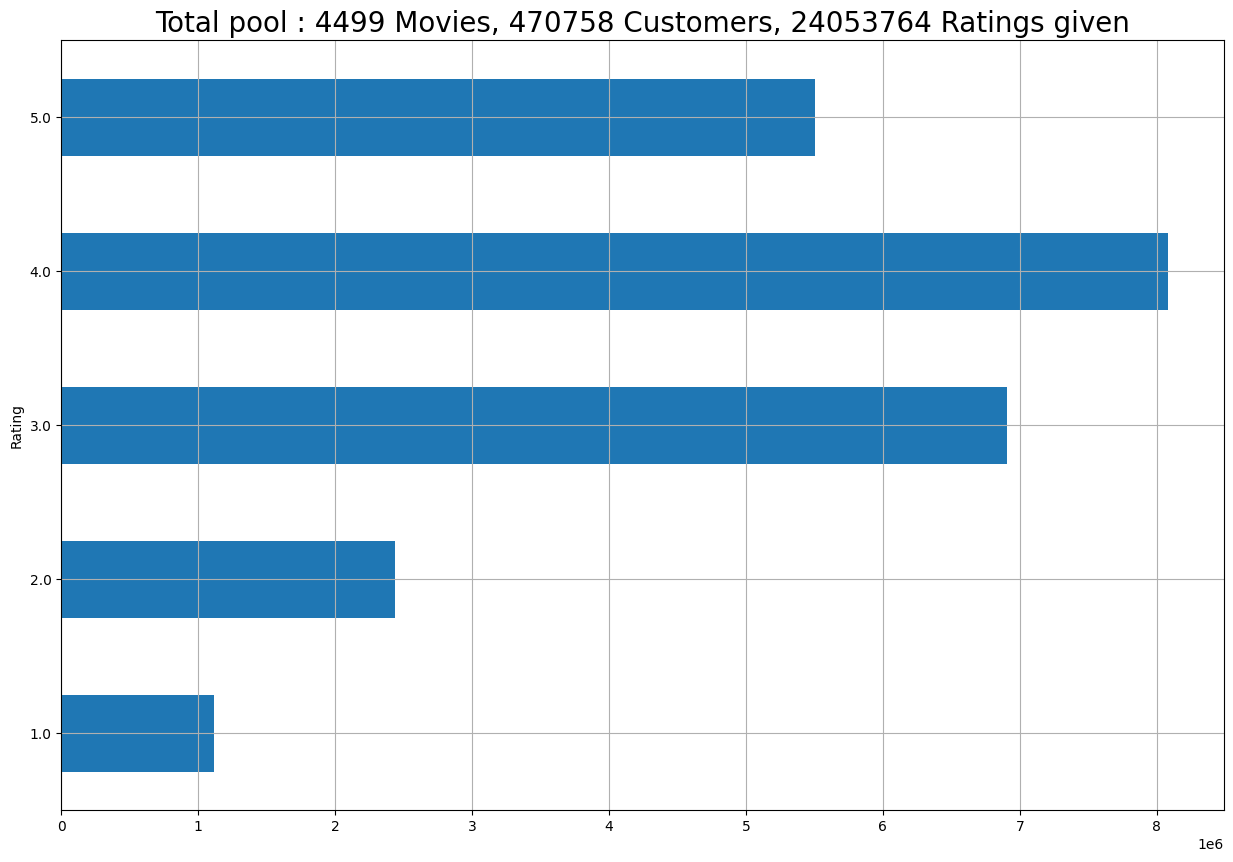

In [16]:
ax = stars.plot(kind='barh', legend=False, figsize=(15,10))
plt.title(f'Total pool : {movie_count} Movies, {customer_count} Customers, {rating_count} Ratings given', fontsize = 20)
plt.grid(True)

In [17]:
movie_id = None
movie_np = []
# Iterate over the DataFrame rows
for cust_id in netflix_dataset['Cust_Id']:
  if ":" in cust_id:
    # Update the current movie ID
    movie_id = int(cust_id.replace(':',''))
  movie_np.append(movie_id)

In [18]:
# Adding the new column to the DataFrame
netflix_dataset['Movie_Id'] = movie_np

In [19]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [20]:
# Dropping the NaN Values
netflix_dataset.dropna(inplace = True)

In [21]:
netflix_dataset.head()

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [22]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [23]:
netflix_dataset['Cust_Id'] = netflix_dataset['Cust_Id'].astype('int')

In [24]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [25]:
# Pre-Filtering
# Now we will Remove all the users that had Ratedless movies and also all those movies that has been rated less in number

dataset_movie_summary = netflix_dataset.groupby('Movie_Id')['Rating'].agg(['count'])

In [26]:
dataset_movie_summary.head()

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140


In [27]:
# Creating a Benchmark
movie_benchmark = round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [28]:
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count'] < movie_benchmark].index
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [29]:
len(drop_movie_list)

2699

In [30]:
# Movie Left
print(movie_count-len(drop_movie_list))

1800


In [31]:
# Removing all the in-active Users
dataset_cust_summary = netflix_dataset.groupby('Cust_Id')['Rating'].agg(['count'])
dataset_cust_summary.head()

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4


In [32]:
cust_benchmark = round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [33]:
drop_cust_list = dataset_cust_summary[dataset_cust_summary['count'] < cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [34]:
len(drop_cust_list)

282042

In [35]:
netflix_dataset = netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
print(f'After the triming, the shape is : {format(netflix_dataset.shape)}')

After the triming, the shape is : (19695836, 3)


## `Model Building`

#### Dataset - https://drive.google.com/file/d/1Zt7Z3EDNcQvJJT0tiqZiBbqnK0RSRGzT/view

In [36]:
df_title = pd.read_csv('/content/drive/MyDrive/movie_titles.csv', encoding='latin1', header=None, usecols=[0,1,2], names=['Movie_Id', 'Year', 'Name'])
df_title.head()

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [37]:
!pip install 'numpy<2.0.0'

In [38]:
! pip install scikit-surprise

In [39]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [40]:
reader = Reader()

In [41]:
#we only work with top 100K rows for quick runtime
data=Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']][:100000], reader)

In [42]:
model=SVD()

In [43]:
cross_validate(model, data, measures=['RMSE'], cv=3)

{'test_rmse': array([1.01527025, 1.01848755, 1.02228006]),
 'fit_time': (2.045104742050171, 1.6521272659301758, 2.520382881164551),
 'test_time': (0.26055312156677246, 0.6038246154785156, 0.5918049812316895)}

## `Recommendation`

In [44]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [45]:
df_title.head()

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [46]:
user_1331154	=df_title.copy()   #making a copy for each individual customer for the recomendation
user_1331154

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [48]:
user_1331154=user_1331154[~user_1331154['Movie_Id'].isin(drop_movie_list)]  #Benchmark
user_1331154

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [49]:
user_1331154['Estimate_Score']=user_1331154['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)

/tmp/ipykernel_2071/1053852032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154['Estimate_Score']=user_1331154['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)


In [50]:
user_1331154['Estimate_Score']

,Estimate_Score
0,3.661559
1,3.661559
2,3.802696
3,3.661559
4,3.947184
...,...
17765,3.661559
17766,3.661559
17767,3.661559
17768,3.661559


In [51]:
user_1331154.sort_values('Estimate_Score', ascending=False)

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.471370
4,5,2004.0,The Rise and Fall of ECW,3.947184
17,18,1994.0,Immortal Beloved,3.895734
2,3,1997.0,Character,3.802696
7,8,2004.0,What the #$*! Do We Know!?,3.712834
...,...,...,...,...
5,6,1997.0,Sick,3.195011
23,24,1981.0,My Bloody Valentine,3.190375
16,17,2005.0,7 Seconds,3.136070
15,16,1996.0,Screamers,3.058927


In [52]:
top5_movies=user_1331154.sort_values('Estimate_Score', ascending=False).head(5)
top5_movies

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.471370
4,5,2004.0,The Rise and Fall of ECW,3.947184
17,18,1994.0,Immortal Beloved,3.895734
2,3,1997.0,Character,3.802696
7,8,2004.0,What the #$*! Do We Know!?,3.712834
